# Data Quality Assessment — Online Retail Dataset

**Dataset:** UCI *Online Retail* — 541,909 transactions from a UK-based, registered, non-store online retailer between 01/Dec/2010 and 09/Dec/2011.

**KPIs assessed:** Completeness, Latency, Accuracy, Consistency.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
plt.rcParams.update({'figure.dpi': 110, 'savefig.bbox': 'tight'})

DATA_PATH = 'Online Retail.csv'  # adjust if needed
TODAY = pd.Timestamp('2026-04-26')  # analysis run date

## 2. Load and inspect

In [2]:
df = pd.read_csv(DATA_PATH, encoding='latin-1')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
print('Shape:', df.shape)
df.head()

Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

## 3. Descriptive statistics

In [4]:
df[['Quantity', 'UnitPrice']].describe().round(2)

,Quantity,UnitPrice
count,541909.00,541909.00
mean,9.55,4.61
std,218.08,96.76
min,-80995.00,-11062.06
25%,1.00,1.25
50%,3.00,2.08
75%,10.00,4.13
max,80995.00,38970.00


In [5]:
print('Unique invoices :', df['InvoiceNo'].nunique())
print('Unique customers:', df['CustomerID'].nunique())
print('Unique stock IDs:', df['StockCode'].nunique())
print('Unique countries:', df['Country'].nunique())
print('Date range      :', df['InvoiceDate'].min(), '->', df['InvoiceDate'].max())

Unique invoices : 25900
Unique customers: 4372
Unique stock IDs: 4070
Unique countries: 38
Date range      : 2010-12-01 08:26:00 -> 2011-12-09 12:50:00


## 4. Basic visualizations

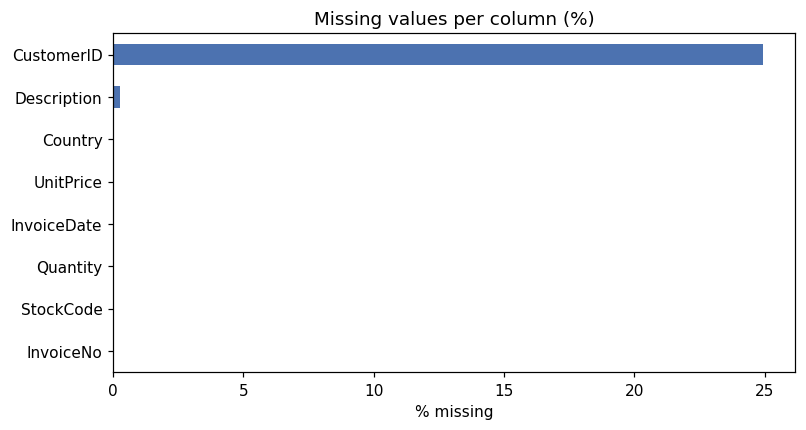

In [6]:
# Missing values per column
missing_pct = (df.isna().mean() * 100).round(2).sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
missing_pct.plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_title('Missing values per column (%)')
ax.set_xlabel('% missing')
plt.show()

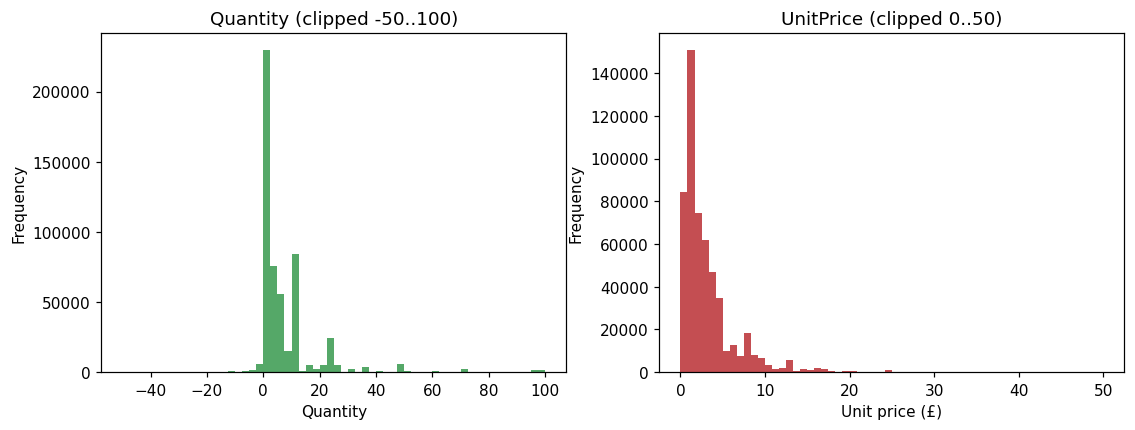

In [7]:
# Quantity & UnitPrice distributions (clipped to readable ranges)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df.loc[df['Quantity'].between(-50, 100), 'Quantity'].plot(
    kind='hist', bins=60, ax=axes[0], color='#55A868')
axes[0].set_title('Quantity (clipped -50..100)'); axes[0].set_xlabel('Quantity')
df.loc[df['UnitPrice'].between(0, 50), 'UnitPrice'].plot(
    kind='hist', bins=60, ax=axes[1], color='#C44E52')
axes[1].set_title('UnitPrice (clipped 0..50)'); axes[1].set_xlabel('Unit price (£)')
plt.show()

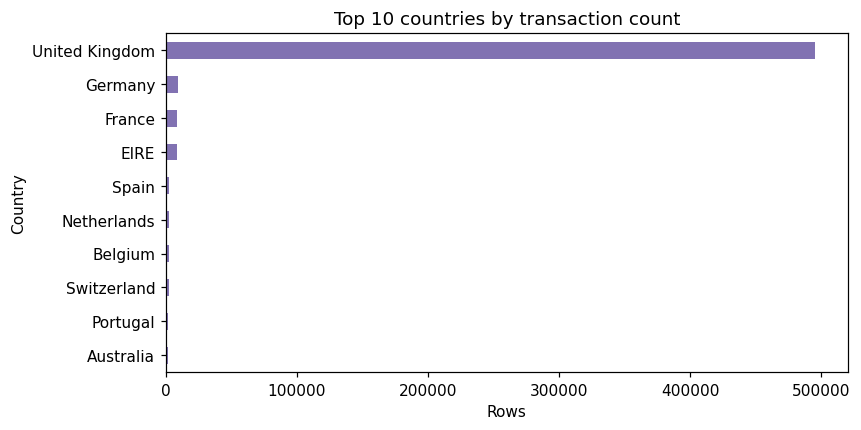

In [8]:
# Top 10 countries by transaction count
top_countries = df['Country'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(8, 4))
top_countries.sort_values().plot(kind='barh', ax=ax, color='#8172B2')
ax.set_title('Top 10 countries by transaction count')
ax.set_xlabel('Rows')
plt.show()

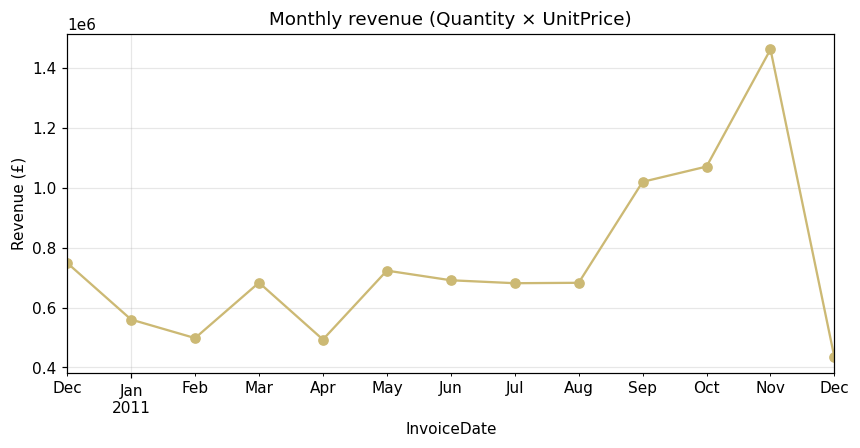

In [9]:
# Monthly revenue
df['Revenue'] = df['Quantity'] * df['UnitPrice']
monthly = df.set_index('InvoiceDate').resample('MS')['Revenue'].sum()
fig, ax = plt.subplots(figsize=(9, 4))
monthly.plot(ax=ax, marker='o', color='#CCB974')
ax.set_title('Monthly revenue (Quantity × UnitPrice)')
ax.set_ylabel('Revenue (£)'); ax.grid(alpha=0.3)
plt.show()

## 5. KPI — (a) Completeness

**Definition.** Share of expected values that are actually present, computed cell-wise.  
**Formula.** `Completeness = (1 − missing_cells / total_cells) × 100%`.

In [10]:
missing_per_col = df.drop(columns=['Revenue']).isna().sum()
missing_pct_per_col = (df.drop(columns=['Revenue']).isna().mean() * 100).round(2)
n_rows, n_cols = df.drop(columns=['Revenue']).shape
total_missing = int(missing_per_col.sum())
overall_completeness = round((1 - total_missing / (n_rows * n_cols)) * 100, 2)

print('Missing per column:'); print(missing_per_col)
print('\nMissing %:');         print(missing_pct_per_col)
print('\nOverall completeness: {}%'.format(overall_completeness))

Missing per column:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Missing %:
InvoiceNo       0.00
StockCode       0.00
Description     0.27
Quantity        0.00
InvoiceDate     0.00
UnitPrice       0.00
CustomerID     24.93
Country         0.00
dtype: float64

Overall completeness: 96.85%


**Reading.** Two columns drive almost all the missingness:
- `CustomerID` is null on **24.93%** of rows — a serious gap because customer identity is the join key for any user-level model.
- `Description` is null on **0.27%** of rows — minor.
All other columns are 100% populated.

## 6. KPI — (b) Latency

**Definition.** How current the data is. For an AI training dataset, latency is the gap between when a real-world event occurred and when the data was available for use today.  
**Two views:**
1. *Freshness* — days between the most recent record and today.
2. *Median record age* — median age of all rows.

In [11]:
data_max = df['InvoiceDate'].max()
freshness_days = (TODAY - data_max).days
median_age_days = int((TODAY - df['InvoiceDate']).dt.days.median())

print('Most recent record :', data_max)
print('Today              :', TODAY.date())
print('Freshness (days)   :', freshness_days)
print('Median age (days)  :', median_age_days)
print('That is roughly    : {:.1f} years stale'.format(freshness_days / 365.25))

Most recent record : 2011-12-09 12:50:00
Today              : 2026-04-26
Freshness (days)   : 5251
Median age (days)  : 5394
That is roughly    : 14.4 years stale


## 7. KPI — (c) Accuracy

**Definition.** Share of rows whose values respect the business rules and physical sanity of the domain.  
**Rules applied:**
- `Quantity > 0` (negative values are returns; zero is impossible)
- `UnitPrice > 0` (zero or negative is invalid for a sale)
- `InvoiceNo` does not start with `'C'` (those are cancellations, not real sales)

We also flag IQR outliers separately so they can be inspected without being thrown away.

In [12]:
is_cancel = df['InvoiceNo'].astype(str).str.startswith('C')
neg_qty   = int((df['Quantity'] < 0).sum())
zero_qty  = int((df['Quantity'] == 0).sum())
neg_price = int((df['UnitPrice'] < 0).sum())
zero_price = int((df['UnitPrice'] == 0).sum())
cancellations = int(is_cancel.sum())

valid_mask = (df['Quantity'] > 0) & (df['UnitPrice'] > 0) & (~is_cancel)
accuracy_pct = round(valid_mask.mean() * 100, 2)

def iqr_outliers(s):
    s = s.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return int(((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum())

print('Negative quantity rows :', neg_qty)
print('Zero quantity rows     :', zero_qty)
print('Negative price rows    :', neg_price)
print('Zero price rows        :', zero_price)
print('Cancellation invoices  :', cancellations)
print('IQR outliers Quantity  :', iqr_outliers(df['Quantity']))
print('IQR outliers UnitPrice :', iqr_outliers(df['UnitPrice']))
print('\nAccuracy (valid rows): {}%'.format(accuracy_pct))

Negative quantity rows : 10624
Zero quantity rows     : 0
Negative price rows    : 2
Zero price rows        : 2515
Cancellation invoices  : 9288
IQR outliers Quantity  : 58619
IQR outliers UnitPrice : 39627

Accuracy (valid rows): 97.82%


## 8. KPI — (d) Consistency

**Definition.** Internal coherence of the data — same fact represented the same way every time.  
**Checks:**
1. Fully-duplicated rows.
2. One `StockCode` should map to exactly one `Description`.
3. Country strings shouldn't have leading/trailing whitespace or mixed casing for the same country.

In [13]:
full_dupes = int(df.drop(columns=['Revenue']).duplicated().sum())
duplicate_free_pct = round((1 - full_dupes / len(df)) * 100, 2)

desc_per_stock = df.dropna(subset=['Description']).groupby('StockCode')['Description'].nunique()
codes_with_multi = int((desc_per_stock > 1).sum())
total_codes = int(desc_per_stock.shape[0])
desc_consistency_pct = round((1 - codes_with_multi / total_codes) * 100, 2)

country_ws = int((df['Country'].astype(str) != df['Country'].astype(str).str.strip()).sum())

consistency_pct = round((duplicate_free_pct + desc_consistency_pct) / 2, 2)

print('Fully duplicated rows           :', full_dupes, '   ({}% duplicate-free)'.format(duplicate_free_pct))
print('StockCodes with multiple descs  :', codes_with_multi, '/', total_codes,
      '   ({}% consistent)'.format(desc_consistency_pct))
print('Country whitespace issues       :', country_ws)
print('\nBlended consistency score      : {}%'.format(consistency_pct))

Fully duplicated rows           : 5268    (99.03% duplicate-free)
StockCodes with multiple descs  : 650 / 3958    (83.58% consistent)
Country whitespace issues       : 0

Blended consistency score      : 91.31%


## 9. KPI scorecard

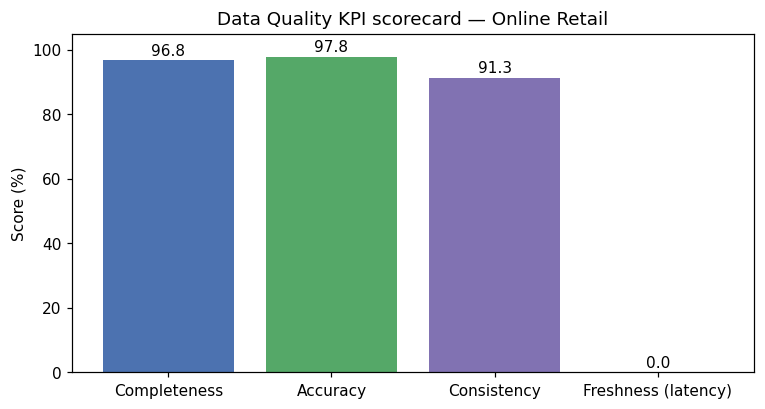

,KPI,Score (%)
0,Completeness,96.85
1,Accuracy,97.82
2,Consistency,91.31
3,Freshness (latency),0.00


In [14]:
freshness_score = round(max(0, 100 - freshness_days / 30), 2)  # 1 point lost per month stale
kpi = {
    'Completeness': overall_completeness,
    'Accuracy':     accuracy_pct,
    'Consistency':  consistency_pct,
    'Freshness (latency)': freshness_score,
}

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#4C72B0', '#55A868', '#8172B2', '#CCB974']
bars = ax.bar(kpi.keys(), kpi.values(), color=colors)
ax.set_ylim(0, 105); ax.set_ylabel('Score (%)')
ax.set_title('Data Quality KPI scorecard — Online Retail')
for b, v in zip(bars, kpi.values()):
    ax.text(b.get_x()+b.get_width()/2, v+1.5, f'{v:.1f}', ha='center', fontsize=10)
plt.show()

pd.DataFrame({'KPI': list(kpi.keys()), 'Score (%)': list(kpi.values())})